# 06 — Signal Generation

---

## Objective

The objective is to transform Bayesian mispricing estimates into systematic trading signals.

In the previous phase, we estimated:

$ Mispricing = P_{Bayes} - P_{Market} $ 

where:

- $ P_{Bayes} $ is the Bayesian fair probability.
- $ P_{Market} $ is the market-implied probability.

This notebook defines when a mispricing estimate is large enough to generate an actionable signal.

---

## Research Question

Can Bayesian fair-value deviations be transformed into systematic trading signals?

---

## Signal Intuition

If: $ P_{Bayes} > P_{Market} $

then the market may be underpricing the event.

This suggests a potential:

- BUY signal If:
$ P_{Bayes} <P_{Market} $
	​
then the market may be overpricing the event.

This suggests a potential: SELL signal.

If the difference is small, the signal is likely noise.

This suggests:

NO TRADE 

Signal Rule

A simple threshold-based rule will be used:

$ Signal = \begin{cases} BUY, & Mispricing > \tau \\  SELL, & Mispricing < -\tau \\  NO\ TRADE, & otherwise \end{cases}$


where: $ τ $ 

is the minimum mispricing threshold required to enter a trade.

Key Questions


1. How many signals are generated for different thresholds?
2. Are signals concentrated in specific probability regions?
3. Do BUY and SELL signals appear balanced?
4. Are signal magnitudes large enough to justify trading?
5. Which markets generate the strongest signals?


In [ ]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

df_signal = pd.read_csv("../data/processed/market_dataset_with_fair_value.csv")
    

Missing columns: []


,market_id,question,final_probability,bayesian_fair_probability,mispricing,outcome
0,248594,Will Hunter Biden be federally indicted by May...,0.020,0.038462,0.018462,0
1,249778,MLB: Cincinnati Reds vs. Pittsburgh Pirates 20...,0.550,0.600000,0.050000,1
2,250474,Did US GDP grow 2.5% or more in Q1 2023?,0.360,0.333333,-0.026667,0
3,251025,Will Ron DeSantis file to run for president by...,0.995,0.900000,-0.095000,1
4,251027,USD/TRY (Turkish Lira) above 19.75 on May 22?,0.825,0.666667,-0.158333,1


In [2]:
def generate_signal(mispricing, threshold=0.05):
    if mispricing > threshold:
        return "BUY"
    elif mispricing < -threshold:
        return "SELL"
    else:
        return "NO TRADE"


threshold = 0.05

df_signal["signal"] = df_signal["mispricing"].apply(lambda x: generate_signal(x, threshold=threshold))

print("signal distribution:")
print(df_signal["signal"].value_counts())

display(df_signal[["market_id","question","final_probability","bayesian_fair_probability","mispricing",
            "signal","outcome"]].sort_values("mispricing", ascending=False).head(5))

signal distribution:
signal
NO TRADE    28
SELL        12
BUY          3
Name: count, dtype: int64


,market_id,question,final_probability,bayesian_fair_probability,mispricing,signal,outcome
7,252047,Will Dillon Danis post 5+ pics of Nina on Aug ...,0.2350,0.500000,0.265000,BUY,1
19,253384,Elizabeth Warren crypto bill become law by June?,0.2350,0.500000,0.265000,BUY,0
42,255410,US inflation >0.4% from Feb to March 2024?,0.5350,0.600000,0.065000,BUY,0
1,249778,MLB: Cincinnati Reds vs. Pittsburgh Pirates 20...,0.5500,0.600000,0.050000,NO TRADE,1
30,254573,Will Fed cut interest rates 1 time in 2024?,0.0005,0.038462,0.037962,NO TRADE,0


## Signal Generation 

### Most Markets Do Not Generate a Trade

Using a baseline threshold of:

$\tau = 0.05$

the signal distribution is:

| Signal | Count |
|---------|-------:|
| BUY | 3 |
| SELL | 12 |
| NO TRADE | 28 |

Most markets remain inside the no-trade region, suggesting that market and Bayesian fair values are generally aligned.

---

###  SELL Signals Dominate

The model generates:

$12$ SELL signals versus $3$ BUY signals.

This indicates that the Bayesian model frequently estimates: $P_{Bayes} < P_{Market}$

suggesting that the market may be more optimistic than the historical Bayesian calibration.

---

### Strong Positive Mispricings Exist

The largest BUY opportunities exhibit: $Mispricing \approx +26.5\%$

These markets represent the strongest disagreement between market-implied probabilities and Bayesian fair values.

---

### Large Mispricing Does Not Guarantee Correct Predictions

Among the three BUY signals:

* 1 market resolved successfully.
* 2 markets resolved unsuccessfully.

This highlights an important distinction:

Large mispricing does not automatically imply a profitable signal.

---

### Threshold Selection Matters

The current threshold:  $\tau = 0.05$

is only a baseline.

Different thresholds may substantially change:

* Number of signals
* BUY/SELL balance
* Signal quality
* Potential profitability

A threshold sensitivity analysis is required before proceeding to backtesting.

---

### Conclusion

The Bayesian framework is capable of generating actionable signals, but the current threshold produces relatively few BUY opportunities and a larger number of SELL signals.

The next step is to evaluate how signal generation changes across multiple thresholds and determine whether stronger mispricing levels produce cleaner trading opportunities.

## Threshold Sensitivity Analysis

The objective of this section is to study how the trading signal behaves under different mispricing thresholds.

A threshold that is too small may generate excessive noise and overtrading.

Conversely, a threshold that is too large may eliminate potentially valuable opportunities.

To understand this tradeoff, we evaluate thresholds ranging from:

$\tau = 0.01$ to  $\tau = 0.20$

For each threshold, we measure:

* Number of BUY signals
* Number of SELL signals
* Total number of trades

This analysis provides insight into the stability and practical usability of the Bayesian mispricing signal before performing any backtesting.

In [3]:
thresholds = np.arange(0.01, 0.21, 0.01)
results = []

for tau in thresholds:

    temp = df_signal.copy()

    temp["signal"] = temp["mispricing"].apply(lambda x: generate_signal(x,threshold=tau))

    n_buy = (temp["signal"] == "BUY").sum()

    n_sell = (temp["signal"] == "SELL").sum()

    n_trades = (temp["signal"] != "NO TRADE").sum()

    results.append({
        "threshold": round(tau, 2),
        "buy_signals": n_buy,
        "sell_signals": n_sell,
        "total_trades": n_trades})
    

df_thresholds = pd.DataFrame(results)

display(df_thresholds)

,threshold,buy_signals,sell_signals,total_trades
0,0.01,26,17,43
1,0.02,25,16,41
2,0.03,22,13,35
3,0.04,4,13,17
4,0.05,3,12,15
5,0.06,3,10,13
6,0.07,2,10,12
7,0.08,2,10,12
8,0.09,2,9,11
9,0.10,2,2,4


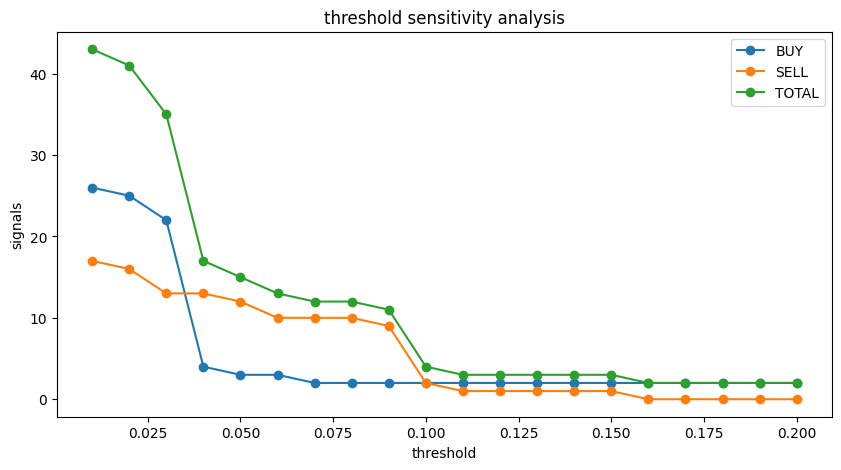

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df_thresholds["threshold"],df_thresholds["buy_signals"],marker="o",label="BUY")
plt.plot(df_thresholds["threshold"],df_thresholds["sell_signals"],marker="o", label="SELL")
plt.plot(df_thresholds["threshold"],df_thresholds["total_trades"],marker="o",label="TOTAL")
plt.xlabel("threshold")
plt.ylabel("signals")
plt.title("threshold sensitivity analysis")
plt.legend()
plt.show()

## Threshold Sensitivity Analysis 

### Signal Count Collapses Rapidly

For very small thresholds:

$\tau \in [0.01, 0.03]$

the model generates:

* More than 35 trades
* A large number of BUY and SELL signals

This indicates that small Bayesian deviations are extremely common.

However, many of these signals are likely statistical noise.

---

### A Natural Breakpoint Appears Around 4–5%

A sharp decline occurs between:

$\tau = 0.03$ and $\tau = 0.05$

Total signals drop dramatically.

This suggests that most mispricing observations are relatively small and concentrated below approximately 5%.

---

### Signal Stability Emerges Around 7–10%

For:

$\tau \approx 0.07 - 0.10$

the number of signals stabilizes.

The model generates approximately:

* 2–3 BUY signals
* 2–10 SELL signals

This region may represent a better balance between:

* Signal quality
* Signal quantity

and therefore deserves further investigation.

---

### Strong Signals Are Extremely Rare

For:

$\tau > 0.15$

almost all signals disappear.

Only a handful of extreme mispricing observations survive.

This indicates that very large deviations between market probabilities and Bayesian fair values are uncommon.

---

### The Market Appears Reasonably Efficient

If substantial inefficiencies were widespread, signal counts would remain high even for larger thresholds.

Instead, the number of signals rapidly converges toward zero.

This is consistent with previous findings:

* Low Brier Score
* Low ECE
* Mispricing centered around zero

Overall, the market appears broadly calibrated and efficient.

---

### Conclusion

The threshold analysis reveals a clear tradeoff:

* Small thresholds generate many noisy signals.
* Large thresholds eliminate nearly all opportunities.

The most promising region appears to lie between:

$\tau = 0.05$ and $\tau = 0.10$

where the Bayesian model still identifies meaningful disagreements while avoiding excessive signal generation.

## Signal Quality Analysis

Generating signals is only the first step.

A useful signal must not only identify market disagreements, but also correctly predict future outcomes.

In this section, we evaluate the predictive quality of the Bayesian mispricing signal across multiple thresholds.

For each threshold, we measure:

* Number of generated trades
* BUY signal accuracy
* SELL signal accuracy
* Overall signal accuracy

This allows us to determine whether stronger mispricing signals correspond to higher predictive power before introducing any trading or portfolio assumptions.

In [6]:
# Evaluating all the threshold
thresholds = np.arange(0.01, 0.21, 0.01)
quality_results = []

for tau in thresholds:

    temp = df_signal.copy()
    temp["signal"] = temp["mispricing"].apply(lambda x: generate_signal(x,threshold=tau))
    trades = temp[temp["signal"] != "NO TRADE"].copy()

    if len(trades) == 0:
        continue

    trades["correct"] = np.where(((trades["signal"] == "BUY") & (trades["outcome"] == 1)) | ((trades["signal"] == "SELL")& (trades["outcome"] == 0)
        ),1,0)

    overall_accuracy = trades["correct"].mean()

    buy_accuracy = (trades.loc[trades["signal"] == "BUY","correct"].mean())

    sell_accuracy = (trades.loc[trades["signal"] == "SELL","correct"].mean())

    quality_results.append({
        "threshold": tau,
        "n_trades": len(trades),
        "buy_accuracy": buy_accuracy,
        "sell_accuracy": sell_accuracy,
        "overall_accuracy": overall_accuracy})

df_quality = pd.DataFrame(quality_results)
display(df_quality)

,threshold,n_trades,buy_accuracy,sell_accuracy,overall_accuracy
0,0.01,43,0.115385,0.352941,0.209302
1,0.02,41,0.120000,0.312500,0.195122
2,0.03,35,0.136364,0.153846,0.142857
3,0.04,17,0.500000,0.153846,0.235294
4,0.05,15,0.333333,0.083333,0.133333
5,0.06,13,0.333333,0.100000,0.153846
6,0.07,12,0.500000,0.100000,0.166667
7,0.08,12,0.500000,0.100000,0.166667
8,0.09,11,0.500000,0.111111,0.181818
9,0.10,4,0.500000,0.000000,0.250000


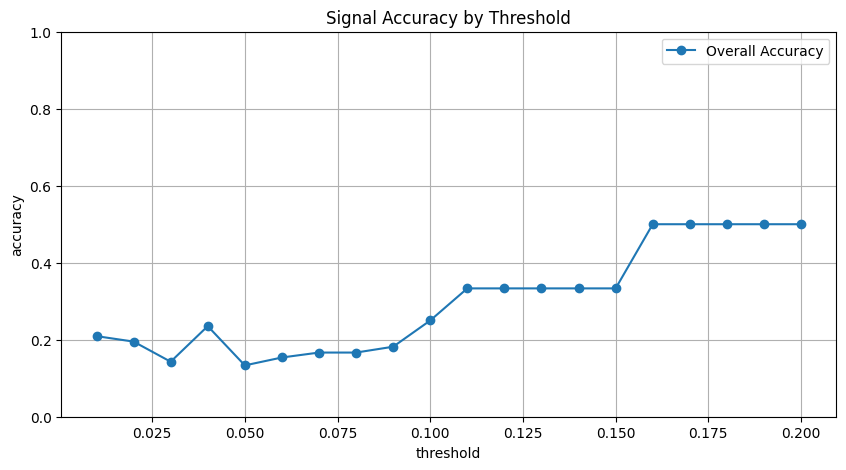

In [7]:
# plotting  Accuracy vs Threshold
plt.figure(figsize=(10,5))

plt.plot(df_quality["threshold"],df_quality["overall_accuracy"],marker="o",label="Overall Accuracy")
plt.xlabel("threshold")
plt.ylabel("accuracy")
plt.title("Signal Accuracy by Threshold")
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.show()

## Signal Quality Results

The Bayesian mispricing signal generated meaningful probability deviations relative to market-implied probabilities.

However, threshold sensitivity analysis revealed limited predictive power.

Although stronger thresholds reduced the number of generated signals, signal accuracy did not improve materially.

The highest observed accuracy reached approximately 50%, but only with two trades, making statistical inference unreliable.

These results suggest that while Bayesian fair values differ from market probabilities, the resulting discrepancies do not appear to generate robust predictive signals within the current sample.

This finding is consistent with previous calibration results indicating that prediction markets are already relatively efficient and well calibrated.

## BUY-Only Signal Analysis

The previous analysis evaluated both BUY and SELL signals simultaneously.

However, it is possible that predictive information exists only on one side of the market.

To investigate this possibility, we evaluate a BUY-only strategy.

A BUY signal is generated whenever:

$Mispricing > \tau$

where:

$Mispricing = P_{Bayes} - P_{Market}$

The objective is to determine whether positive Bayesian deviations contain predictive information even if SELL signals do not.

In [8]:
thresholds = np.arange(0.01, 0.21, 0.01)

buy_results = []

for tau in thresholds:

    temp = df_signal.copy()

    buy_trades = temp[temp["mispricing"] > tau].copy()
    n_trades = len(buy_trades)

    if n_trades == 0:
        continue

    accuracy = (buy_trades["outcome"] == 1).mean()

    buy_results.append({
        "threshold": tau,
        "n_trades": n_trades,
        "buy_accuracy": accuracy})

df_buy_only = pd.DataFrame(buy_results)

display(df_buy_only)

,threshold,n_trades,buy_accuracy
0,0.01,26,0.115385
1,0.02,25,0.120000
2,0.03,22,0.136364
3,0.04,4,0.500000
4,0.05,3,0.333333
5,0.06,3,0.333333
6,0.07,2,0.500000
7,0.08,2,0.500000
8,0.09,2,0.500000
9,0.10,2,0.500000


In [9]:
for tau in [0.05, 0.10, 0.15]:

    temp = df_signal.copy()

    buy_trades = temp[temp["mispricing"] > tau]

    print("\nthreshold:", tau)

    print("trades:",len(buy_trades))

    print("accuracy:",(buy_trades["outcome"] == 1).mean())


threshold: 0.05
trades: 3
accuracy: 0.3333333333333333

threshold: 0.1
trades: 2
accuracy: 0.5

threshold: 0.15
trades: 2
accuracy: 0.5


## Signal Generation Conclusions

The Bayesian mispricing framework successfully identified deviations between market-implied probabilities and Bayesian fair values.

However, subsequent signal validation revealed no evidence that these deviations contain meaningful predictive information.

Neither the combined BUY/SELL strategy nor the BUY-only strategy produced accuracy levels materially above random chance.

These findings suggest that prediction markets already incorporate most publicly available information and that simple Beta-Binomial calibration adjustments are insufficient to generate exploitable trading signals.

Future research should explore more sophisticated Bayesian frameworks, market-specific calibration models, dynamic priors, and information-theoretic features.